In [104]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale

import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.preprocessing import scale


In [105]:
# Loaaaaaad the latest version
data_initial = pd.read_csv('data/spotify_songs.csv')

# Variables qualitives
qual_cols = data_initial.select_dtypes(include=['object']).columns
print('Variables qualitatives :', list(qual_cols))

categorical_cols = [
    "playlist_name", 
    "playlist_genre", 
    "playlist_subgenre",
    "mode",
    "key"
]

for col in categorical_cols:
    data_initial[col] = pd.Categorical(data_initial[col], ordered=False)

data_initial.describe()

# Variables quantatives
quant_cols = data_initial.select_dtypes(include=['float64', 'int64']).columns
print('Variables quantitatives :', list(quant_cols))

print(data_initial[categorical_cols].describe())

Variables qualitatives : ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']
Variables quantitatives : ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
          playlist_name playlist_genre          playlist_subgenre   mode  \
count             32833          32833                      32833  32833   
unique              449              6                         24      2   
top     Indie Poptimism            edm  progressive electro house      1   
freq                308           6043                       1809  18574   

          key  
count   32833  
unique     12  
top         1  
freq     4010  


C:\Users\julie\AppData\Local\Temp\ipykernel_24640\1729703984.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qual_cols = data_initial.select_dtypes(include=['object']).columns


In [106]:
# Remove dumb columns and uncomplete lines 

print('=== Non-meaningful columns ===')
# remove identifiers if they exist
cols = ["track_album_id", "playlist_id"]
print('Columns to drop:', cols)
data_initial.drop(columns=cols, errors='ignore', inplace=True)

print('')
print('=== Missing values ===')
print('Columns containing missing values are:', list(data_initial.columns[data_initial.isnull().sum()!=0]))

print('')
print('track_name - Rate of missing values: {:.2f}%'.format(data_initial['track_name'].isnull().sum()/data_initial.shape[0]*100))
print('track_artist - Rate of missing values: {:.2f}%'.format(data_initial['track_artist'].isnull().sum()/data_initial.shape[0]*100))
print('track_album_name - Rate of missing values: {:.2f}%'.format(data_initial['track_album_name'].isnull().sum()/data_initial.shape[0]*100))

print('We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.')

data = data_initial.dropna(subset=['track_name', 'track_artist', 'track_album_name'])

print('')
print('=== Checking ===')
print('Columns containing missing values are:', list(data.columns[data.isnull().sum()!=0]))

data_centered = data.copy()
data_centered[quant_cols] = scale(data[quant_cols])
print(data_centered.columns)

=== Non-meaningful columns ===
Columns to drop: ['track_album_id', 'playlist_id']

=== Missing values ===
Columns containing missing values are: ['track_name', 'track_artist', 'track_album_name']

track_name - Rate of missing values: 0.02%
track_artist - Rate of missing values: 0.02%
track_album_name - Rate of missing values: 0.02%
We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.

=== Checking ===
Columns containing missing values are: []
Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_name', 'track_album_release_date', 'playlist_name',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')


In [107]:
## Remove data below 5th percentile and above 95th percentile
k=0.3
difference = data[quant_cols].quantile(0.95) - data[quant_cols].quantile(0.05)
lower_bounds = data[quant_cols].quantile(0.05) - k*difference
upper_bounds = data[quant_cols].quantile(0.95) + k*difference

mask = np.ones(len(data), dtype=bool)

for col in quant_cols:
    mask &= (data[col] >= lower_bounds[col]) & (data[col] <= upper_bounds[col])

df_clean = data_centered[mask]



In [108]:
print(len(data_centered))
print(len(df_clean))

print(df_clean.describe())
print(df_clean.columns)

32828
29827
       track_popularity  danceability        energy      loudness  \
count      29827.000000  29827.000000  29827.000000  29827.000000   
mean           0.017841      0.044136      0.054428      0.085707   
std            0.999743      0.957223      0.926407      0.872065   
min           -1.700696     -2.790348     -2.800254     -2.867391   
25%           -0.699899     -0.584814     -0.586484     -0.397334   
50%            0.140770      0.138877      0.151440      0.231724   
75%            0.821312      0.745399      0.787104      0.713556   
max            2.302491      2.247920      1.660452      2.196527   

        speechiness  acousticness  instrumentalness      liveness  \
count  29827.000000  29827.000000      29827.000000  29827.000000   
mean      -0.053689     -0.056537         -0.045433     -0.097879   
std        0.880919      0.909924          0.930818      0.785433   
min       -0.835627     -0.798349         -0.377985     -1.171761   
25%       -0.653011  

In [109]:
print(len(quant_cols))

11


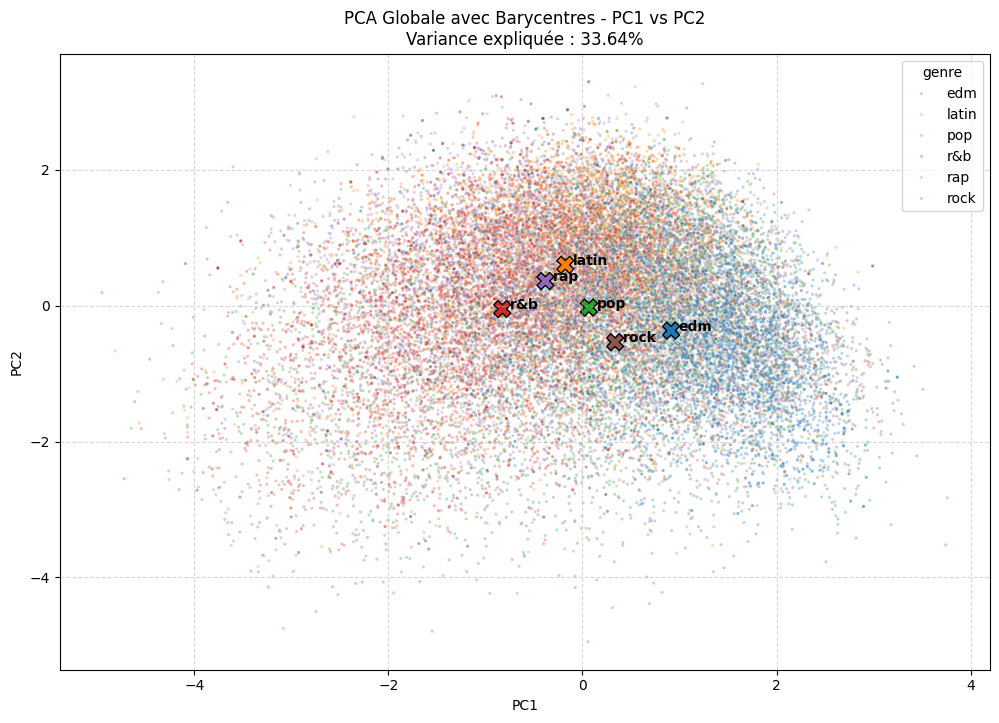

In [110]:
# 2. Calcul de la PCA (on en prévoit 5 pour avoir du choix)
pca_global = PCA(n_components=11)
coords_global = pca_global.fit_transform(df_clean[quant_cols])

# 3. Création du DataFrame
columns = [f'PC{i+1}' for i in range(11)]
df_pca_global = pd.DataFrame(coords_global, columns=columns)
df_pca_global['genre'] = df_clean['playlist_genre'].values


# --- TA CONFIGURATION ---
cp_x = 'PC1' 
cp_y = 'PC2' 
# -------------------------

# 1. Calcul des barycentres (moyenne par genre pour les CP choisies)
barycentres = df_pca_global.groupby('genre')[[cp_x, cp_y]].mean().reset_index()

# 2. Visualisation
plt.figure(figsize=(12, 8))

# Affichage des points (individus)
sns.scatterplot(data=df_pca_global, x=cp_x, y=cp_y, hue='genre', alpha=0.3, s=5, legend=True)

# Affichage des barycentres (plus gros, bordure noire pour ressortir)
sns.scatterplot(data=barycentres, x=cp_x, y=cp_y, hue='genre', 
                s=150, edgecolor='black', linewidth=1, legend=False, marker='X')

# Ajout des étiquettes de texte à côté des barycentres pour une lecture directe
for i in range(barycentres.shape[0]):
    plt.text(barycentres.loc[i, cp_x]+0.08, barycentres.loc[i, cp_y], 
             barycentres.loc[i, 'genre'], 
             weight='bold', size=10, color='black')
# Extraction des indices pour la variance (attention au cas où l'index > 9 avec int(cp_x[-1]))
idx_x = int(''.join(filter(str.isdigit, cp_x))) - 1
idx_y = int(''.join(filter(str.isdigit, cp_y))) - 1
var_x = pca_global.explained_variance_ratio_[idx_x]
var_y = pca_global.explained_variance_ratio_[idx_y]

plt.title(f"PCA Globale avec Barycentres - {cp_x} vs {cp_y}\nVariance expliquée : {var_x + var_y:.2%}")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [111]:
# Affichage simple des pourcentages par axe
for i, ratio in enumerate(pca_global.explained_variance_ratio_):
    print(f"PC{i+1} : {ratio:.2%}")


PC1 : 18.52%
PC2 : 15.12%
PC3 : 11.88%
PC4 : 9.62%
PC5 : 9.12%
PC6 : 8.70%
PC7 : 7.33%
PC8 : 6.61%
PC9 : 5.88%
PC10 : 5.04%
PC11 : 2.18%


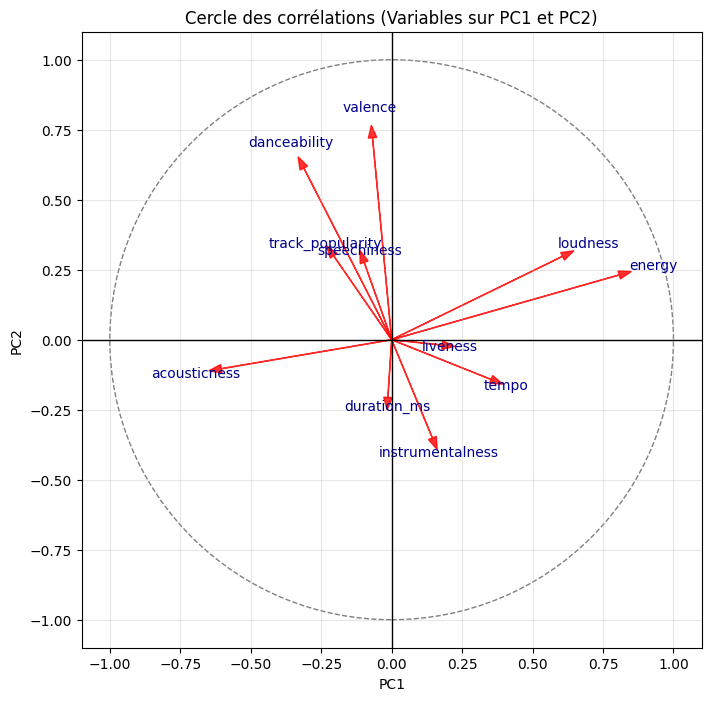

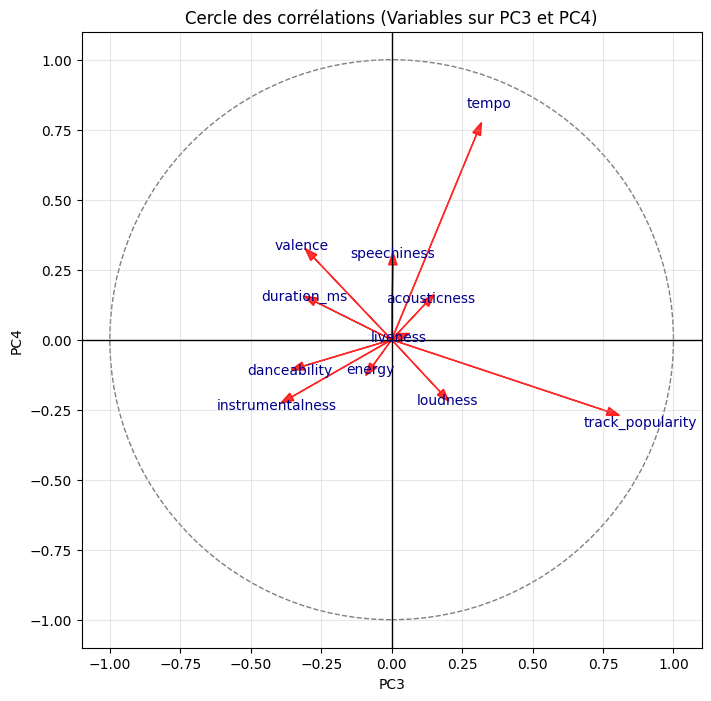

In [112]:
# --- CONFIGURATION : CHOISIS TES CP ICI ---
x_idx = 0  # 0 pour PC1
y_idx = 1  # 1 pour PC2 (change à 2 pour PC3, etc.)
# ------------------------------------------

# 1. Récupération des loadings (coordonnées des variables)
loadings = pca_global.components_.T * np.sqrt(pca_global.explained_variance_)

# 2. Création de la figure
plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# 3. Dessiner les flèches pour chaque variable
for i, var_name in enumerate(quant_cols):
    plt.arrow(0, 0, loadings[i, x_idx], loadings[i, y_idx], 
              color='red', alpha=0.8, head_width=0.03)
    plt.text(loadings[i, x_idx]*1.15, loadings[i, y_idx]*1.15, 
             var_name, color='darkblue', ha='center', va='center')

# 4. Dessiner le cercle unité (optionnel mais recommandé)
cercle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(cercle)



plt.xlabel(f'PC{x_idx+1}')
plt.ylabel(f'PC{y_idx+1}')
plt.title(f'Cercle des corrélations (Variables sur PC{x_idx+1} et PC{y_idx+1})')
plt.grid(True, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.show()

# --- CONFIGURATION : CHOISIS TES CP ICI ---
x_idx = 2  # 0 pour PC1
y_idx = 3  # 1 pour PC2 (change à 2 pour PC3, etc.)
# ------------------------------------------

# 1. Récupération des loadings (coordonnées des variables)
loadings = pca_global.components_.T * np.sqrt(pca_global.explained_variance_)

# 2. Création de la figure
plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# 3. Dessiner les flèches pour chaque variable
for i, var_name in enumerate(quant_cols):
    plt.arrow(0, 0, loadings[i, x_idx], loadings[i, y_idx], 
              color='red', alpha=0.8, head_width=0.03)
    plt.text(loadings[i, x_idx]*1.15, loadings[i, y_idx]*1.15, 
             var_name, color='darkblue', ha='center', va='center')

# 4. Dessiner le cercle unité (optionnel mais recommandé)
cercle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(cercle)

plt.xlabel(f'PC{x_idx+1}')
plt.ylabel(f'PC{y_idx+1}')
plt.title(f'Cercle des corrélations (Variables sur PC{x_idx+1} et PC{y_idx+1})')
plt.grid(True, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.show()

In [137]:
# 1. On prépare le dataframe avec uniquement les colonnes quantitatives dans l'ordre de tes groupes
# 2. Définition des groupes pour la MFA
groups = {
    'G1_Power': ['loudness', 'energy', 'acousticness'],
    'G2_Vibe': ['danceability', 'valence'],
    'G3_SpeechPop': ['track_popularity', 'speechiness'],
    'G4_Duration': ['duration_ms'],
    'G5_TempoLive': ['liveness', 'tempo'],
    'G6_Instrum': ['instrumentalness']
}

# 3. Initialisation et Fit de la MFA
mfa = prince.MFA(
    n_components=11,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(df_clean[quant_cols], groups=groups)

# 4. Récupération des coordonnées des individus
coords_mfa = mfa.transform(df_clean[quant_cols])

coords_mfa.columns = [f'PC{i+1}' for i in range(11)]
coords_mfa['genre'] = df_clean['playlist_genre'].values


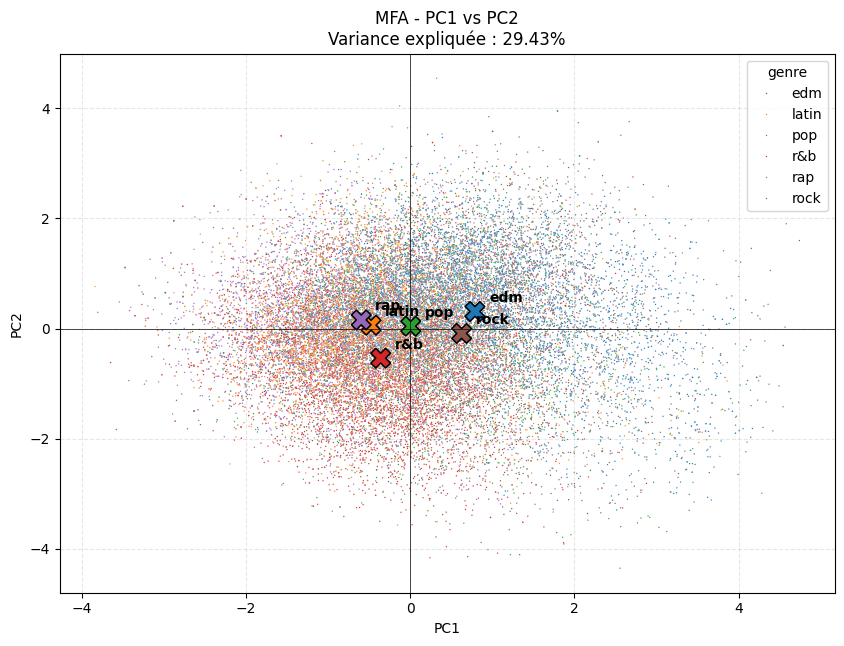

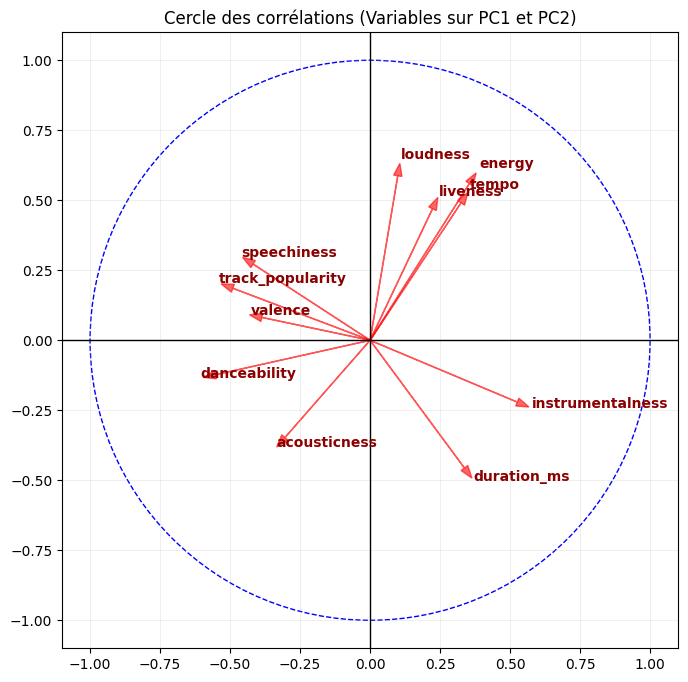

In [144]:
# --- CONFIGURATION ---
cp_x = 'PC1'
cp_y = 'PC2'
# ---------------------

plt.figure(figsize=(10, 7))

# 1. Nuage de points (Individus)
sns.scatterplot(data=coords_mfa, x=cp_x, y=cp_y, hue='genre', alpha=1, s=1)

# 2. Calcul des Barycentres
barycentres = coords_mfa.groupby('genre')[[cp_x, cp_y]].mean().reset_index()

# 3. Affichage des Barycentres (La Croix)
sns.scatterplot(data=barycentres, x=cp_x, y=cp_y, hue='genre', 
                s=200, edgecolor='black', marker='X', legend=False)

# 4. Ajout du texte décalé
offset = (coords_mfa[cp_x].max() - coords_mfa[cp_x].min()) * 0.02 # Offset dynamique
for i in range(len(barycentres)):
    plt.text(barycentres.loc[i, cp_x] + offset, 
             barycentres.loc[i, cp_y] + offset, 
             barycentres.loc[i, 'genre'], weight='bold', size=10)

# --- RÉCUPÉRATION DE LA VARIANCE (Correction de l'exception) ---
# On extrait le numéro de la PC (ex: 'PC1' -> 1) pour trouver le bon index (0)
# Extraction propre des indices (ex: 'PC1' -> 0)
idx_x = int(''.join(filter(str.isdigit, cp_x))) - 1
idx_y = int(''.join(filter(str.isdigit, cp_y))) - 1

eigenvalues = mfa.eigenvalues_
total_variance = sum(eigenvalues)

# Calcul du % de variance manuellement (plus sûr)
var_x = (eigenvalues[idx_x] / total_variance) * 100
var_y = (eigenvalues[idx_y] / total_variance) * 100

plt.title(f"MFA - {cp_x} vs {cp_y}\nVariance expliquée : {var_x + var_y:.2f}%")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


import numpy as np
X=df_clean[quant_cols]
# --- CONFIGURATION DES AXES ---
idx_x = int(''.join(filter(str.isdigit, cp_x))) - 1
idx_y = int(''.join(filter(str.isdigit, cp_y))) - 1

# 1. Calcul des corrélations entre variables originales et axes MFA
# On utilise les colonnes dans l'ordre que tu as défini (cols_ordered)
correlations = X.corrwith(coords_mfa[f'PC{idx_x+1}']).to_frame(name='x')
correlations['y'] = X.corrwith(coords_mfa[f'PC{idx_y+1}'])

# 2. Tracé du graphe
plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# 3. Dessiner les flèches
for i, var_name in enumerate(correlations.index):
    x_val = correlations.iloc[i, 0]
    y_val = correlations.iloc[i, 1]
    
    plt.arrow(0, 0, x_val, y_val, color='red', alpha=0.6, head_width=0.03)
    plt.text(x_val * 1.1, y_val * 1.1, var_name, color='darkred', weight='bold')

# 4. Forcer le cercle et le cadre -1 à 1
cercle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(cercle)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')

plt.title(f"Cercle des corrélations (Variables sur {cp_x} et {cp_y})")
plt.grid(True, alpha=0.2)
plt.show()

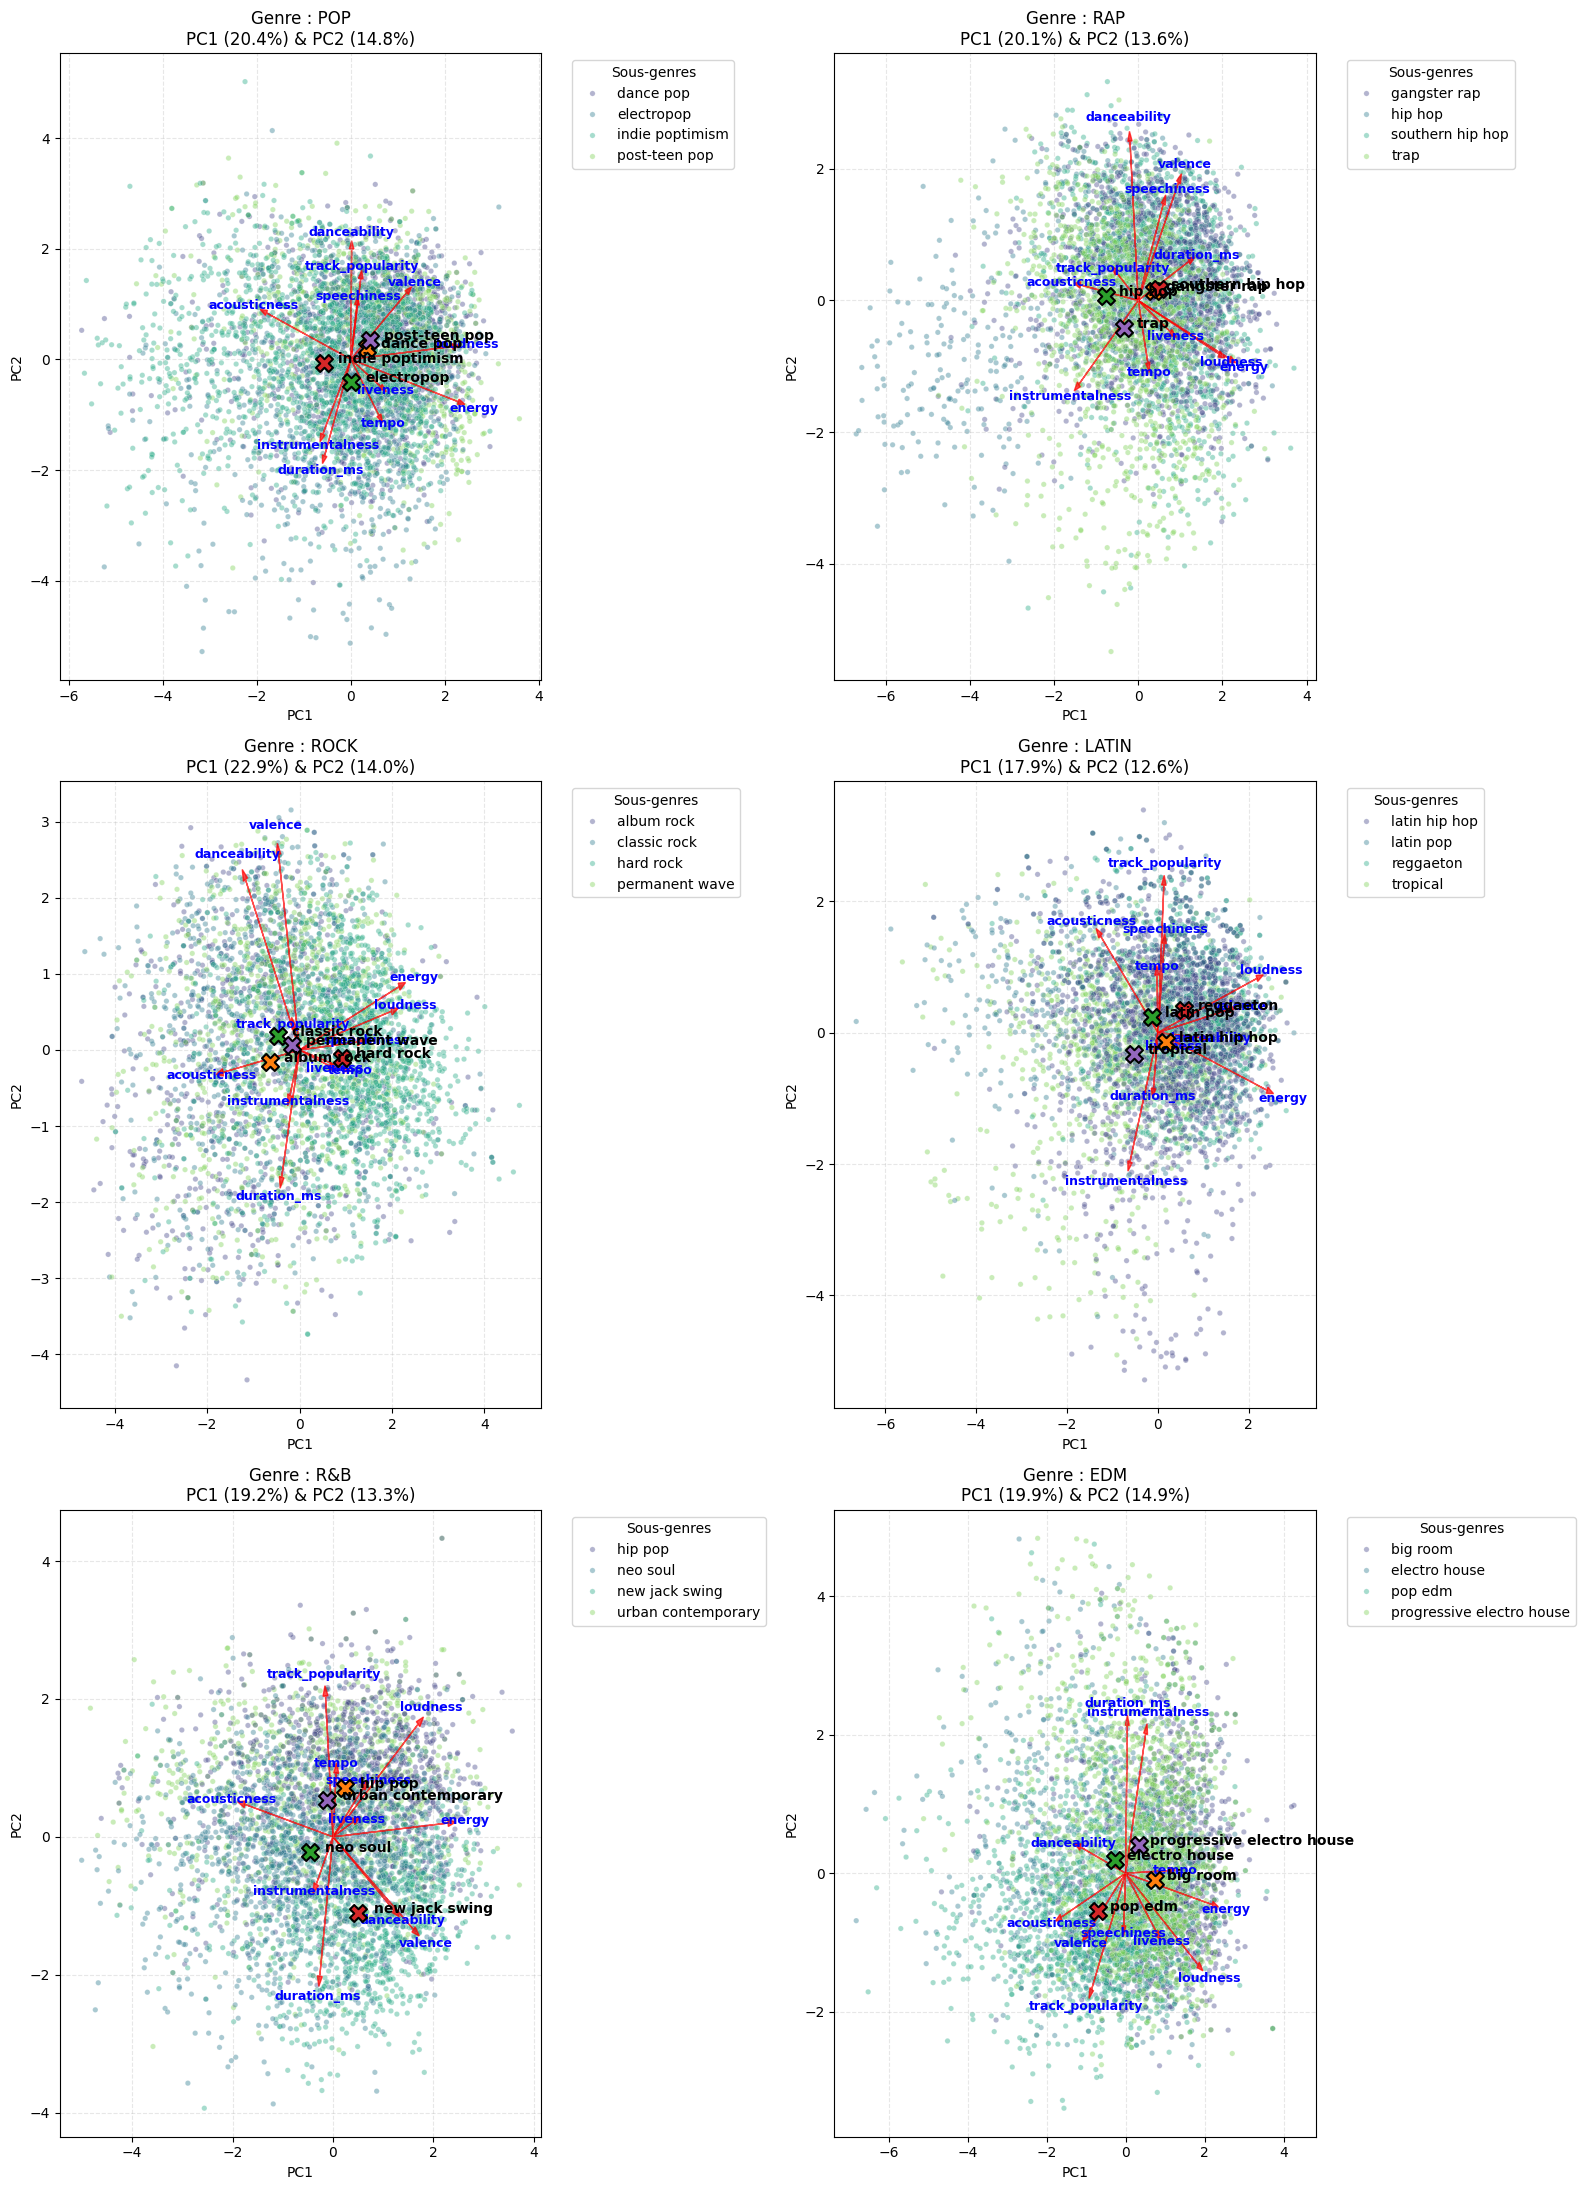

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- CONFIGURATION : CHOISIS TES DIMENSIONS ICI ---
dim_x = 0  # 0 pour PC1, 1 pour PC2, 2 pour PC3, etc.
dim_y = 1  # 1 pour PC2, 2 pour PC3, 3 pour PC4, etc.
coeff = 4  # Facteur d'agrandissement des flèches pour qu'elles soient visibles
# --------------------------------------------------

genres_principaux = df_clean['playlist_genre'].unique()

fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, genre in enumerate(genres_principaux):
    # 1. Filtrer par genre
    sub_df = df_clean[df_clean['playlist_genre'] == genre].copy()
    
    # 2. Normalisation locale
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(sub_df[quant_cols])
    
    # 3. PCA
    n_comp = max(dim_x, dim_y) + 1
    pca_sub = PCA(n_components=n_comp)
    coords = pca_sub.fit_transform(x_scaled)
    
    # 4. Création du DataFrame de plotting
    label_x = f'PC{dim_x + 1}'
    label_y = f'PC{dim_y + 1}'
    plot_df = pd.DataFrame(coords[:, [dim_x, dim_y]], columns=[label_x, label_y])
    sub_df['playlist_subgenre'] = pd.Categorical(sub_df['playlist_subgenre']).remove_unused_categories()
    plot_df['sub_genre'] = sub_df['playlist_subgenre'].values
    
    # 5. Visualisation du nuage de points
    sns.scatterplot(data=plot_df, x=label_x, y=label_y, hue='sub_genre', 
                    ax=axes[i], alpha=0.4, s=15, palette='viridis')
    
    # --- AJOUT DES FLÈCHES (VARIABLES) ---
    # On récupère les coefficients des variables pour les deux axes choisis
    loadings = pca_sub.components_[[dim_x, dim_y], :].T
    
    for j, var in enumerate(quant_cols):
        # On trace la flèche en rouge
        axes[i].arrow(0, 0, loadings[j, 0] * coeff, loadings[j, 1] * coeff, 
                      color='r', alpha=0.7, head_width=0.1)
        # On écrit le nom de la variable
        axes[i].text(loadings[j, 0] * coeff * 1.15, loadings[j, 1] * coeff * 1.15, 
                     var, color='b', fontsize=9, ha='center', va='center', weight='bold')

    # 6. Calcul et affichage des Barycentres
    bary_sub = plot_df.groupby('sub_genre').mean().reset_index()
    offset_x = 0.3
    
    for _, row in bary_sub.iterrows():
        axes[i].scatter(row[label_x], row[label_y], marker='X', s=150, 
                        edgecolor='black', linewidth=1.5, zorder=10)
        axes[i].text(row[label_x] + offset_x, row[label_y], row['sub_genre'], 
                     weight='bold', fontsize=10, zorder=11)
        
    # Calcul de la variance
    var_x = pca_sub.explained_variance_ratio_[dim_x] * 100
    var_y = pca_sub.explained_variance_ratio_[dim_y] * 100
    
    axes[i].set_title(f"Genre : {genre.upper()}\n{label_x} ({var_x:.1f}%) & {label_y} ({var_y:.1f}%)")
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend(title="Sous-genres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()